# Importar Bibliotecas Requeridas
Importa las bibliotecas necesarias como NumPy, Pandas y scikit-learn para el manejo de datos y el entrenamiento del modelo.

In [35]:
# Importar Bibliotecas Requeridas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Verificar Valores Faltantes
Verifica si hay valores NaN en el conjunto de datos antes del preprocesamiento.

In [36]:
# Verificar Valores Faltantes
df_check = pd.read_csv('C:/Users/Carlo/Desktop/owncloud 2025-08-11 ECG/2025-08-11 ECG/2025-08-11/W03/DARA_PROC/combined_features.csv')
print("Total de valores NaN en el conjunto de datos:", df_check.isna().sum().sum())
print("Valores NaN por columna:")
print(df_check.isna().sum())
print("\nTotal de valores cero en las características:", (df_check[['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']] == 0).sum().sum())

Total de valores NaN en el conjunto de datos: 0
Valores NaN por columna:
UNIX Timestamp       0
DateTime             0
ECG_mean             0
ECG_std              0
ECG_range            0
ECG_energy           0
ECG_samp_ent         0
ECG_missing_peaks    0
SDNN                 0
RMSSD                0
pNN50                0
HR_mean              0
HR_max               0
HR_min               0
FatigueIndex         0
dtype: int64

Total de valores cero en las características: 711


# Cargar y Preparar Datos
Carga el conjunto de datos desde combined_features.csv y realiza preprocesamiento como manejar valores faltantes.

In [37]:
# Cargar y Preparar Datos
df = pd.read_csv('C:/Users/Carlo/Desktop/owncloud 2025-08-11 ECG/2025-08-11 ECG/2025-08-11/W03/DARA_PROC/combined_features.csv')

# Seleccionar características y objetivo
features = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
target = 'FatigueIndex'

X = df[features]
y = df[target]

# Manejar valores faltantes (si los hay)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Dividir Datos en Conjuntos de Entrenamiento y Prueba
Usa train_test_split de scikit-learn para dividir los datos en subconjuntos de entrenamiento y prueba.

In [38]:
# Dividir Datos en Conjuntos de Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Elegir e Inicializar un Modelo
Selecciona un algoritmo de aprendizaje automático (ej. LinearRegression) e inicializa el modelo con parámetros predeterminados o personalizados.

In [39]:
# Elegir e Inicializar un Modelo
model = LinearRegression()

# Entrenar el Modelo
Ajusta el modelo a los datos de entrenamiento usando el método fit().

In [40]:
# Entrenar el Modelo
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Evaluar el Rendimiento del Modelo
Evalúa el modelo usando métricas como el error cuadrático medio o R-cuadrado en el conjunto de prueba.

In [41]:
# Evaluar el Rendimiento del Modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error: {mse}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error: {rmse}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error: {mae}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared: {r2}')

Mean Squared Error: 4.714173172516609e-28
Root Mean Squared Error: 2.1712146767458552e-14
Mean Absolute Error: 1.614776792809851e-14
R-squared: 1.0


# Hacer Predicciones
Usa el modelo entrenado para hacer predicciones en datos nuevos o de prueba con el método predict().

In [42]:
# Hacer Predicciones
# Ejemplo: Predecir en datos de prueba
predictions = model.predict(X_test)
print("Predicciones primeras 5:", predictions[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5:", predictions[:5] - y_test.iloc[:5].values)

Predicciones primeras 5: [ 5.31405276 -0.49650086 -2.92220234  1.54488582  0.10442315]
Valores reales primeras 5: [ 5.31405276 -0.49650086 -2.92220234  1.54488582  0.10442315]
Errores (Pred - Real) primeras 5: [-1.77635684e-14  4.99600361e-15  2.66453526e-15 -1.24344979e-14
  1.65423231e-14]


# Importancia de Características (Coeficientes)

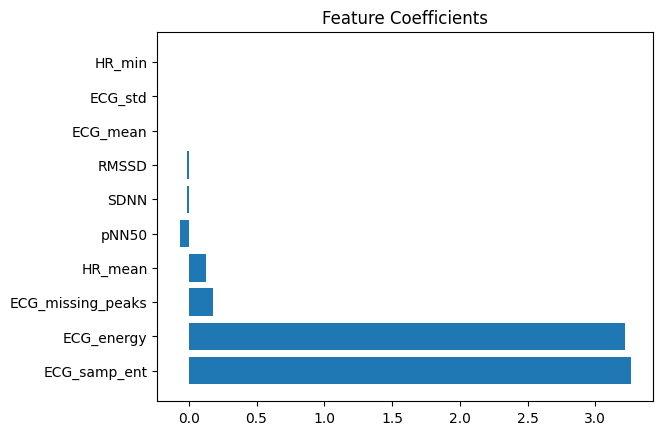

ECG_mean: 0.0000
ECG_std: 0.0000
ECG_range: 0.0000
ECG_energy: 3.2221
ECG_samp_ent: 3.2617
ECG_missing_peaks: 0.1793
SDNN: -0.0124
RMSSD: -0.0107
pNN50: -0.0653
HR_mean: 0.1257
HR_max: 0.0000
HR_min: -0.0000


In [43]:
# Importancia de Características (Coeficientes)
coefficients = model.coef_
feature_names = X_train.columns
# Sort by absolute value for top 10
sorted_idx = np.argsort(np.abs(coefficients))[::-1][:10]
plt.barh(feature_names[sorted_idx], coefficients[sorted_idx])
plt.title("Feature Coefficients")
plt.show()

# Imprimir los coeficientes numéricamente
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

# Experimento 2: Entrenamiento sin Características de HR y HRV

In [44]:
# Experimento 2: Entrenar sin características de HR y HRV
# Remover HR_mean, SDNN, RMSSD, pNN50, HR_max, HR_min de X_train y X_test
features_to_remove = ['HR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_max', 'HR_min']
X_train_new = X_train.drop(columns=features_to_remove)
X_test_new = X_test.drop(columns=features_to_remove)

# y_train, y_test permanecen iguales

In [45]:
# Elegir e Inicializar un Modelo (Experimento 2)
model2 = LinearRegression()

In [46]:
# Entrenar el Modelo (Experimento 2)
model2.fit(X_train_new, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# Evaluar el Rendimiento del Modelo (Experimento 2)
y_pred2 = model2.predict(X_test_new)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error (Exp2): {mse2}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error (Exp2): {rmse2}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error (Exp2): {mae2}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared (Exp2): {r22}')

Mean Squared Error (Exp2): 6.487085243882843
Root Mean Squared Error (Exp2): 2.5469757053970583
Mean Absolute Error (Exp2): 2.0128194393949075
R-squared (Exp2): 0.34176123755140286


In [48]:
# Hacer Predicciones (Experimento 2)
predictions2 = model2.predict(X_test_new)
print("Predicciones primeras 5 (Exp2):", predictions2[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5 (Exp2):", predictions2[:5] - y_test.iloc[:5].values)

Predicciones primeras 5 (Exp2): [ 2.4732747  -1.15585677 -1.4167222   0.28200685 -1.81466108]
Valores reales primeras 5: [ 5.31405276 -0.49650086 -2.92220234  1.54488582  0.10442315]
Errores (Pred - Real) primeras 5 (Exp2): [-2.84077806 -0.65935591  1.50548014 -1.26287897 -1.91908423]


# Importancia de Características (Coeficientes) - Experimento 2

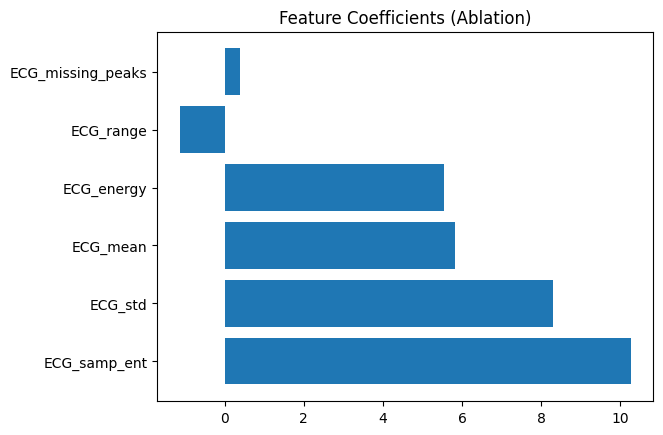

ECG_mean: 5.8139
ECG_std: 8.3124
ECG_range: -1.1341
ECG_energy: 5.5317
ECG_samp_ent: 10.2671
ECG_missing_peaks: 0.3957


In [49]:
# Importancia de Características (Coeficientes) - Experimento 2
coefficients2 = model2.coef_
feature_names2 = X_train_new.columns
# Sort by absolute value for top 10
sorted_idx2 = np.argsort(np.abs(coefficients2))[::-1][:10]
plt.barh(feature_names2[sorted_idx2], coefficients2[sorted_idx2])
plt.title("Feature Coefficients (Ablation)")
plt.show()

# Imprimir los coeficientes numéricamente
for name, coef in zip(feature_names2, coefficients2):
    print(f"{name}: {coef:.4f}")

# Guardar el Modelo Entrenado
Guarda el modelo entrenado en un archivo para poder cargarlo posteriormente y hacer inferencias.

In [50]:
# Guardar el Modelo Entrenado (Experimento 1)
joblib.dump(model, 'linear_regression_model.pkl')
print("Modelo guardado como 'linear_regression_model.pkl'")

Modelo guardado como 'linear_regression_model.pkl'


In [51]:
# Guardar el Modelo Entrenado (Experimento 2)
joblib.dump(model2, 'linear_regression_model_ablation.pkl')
print("Modelo de ablación guardado como 'linear_regression_model_ablation.pkl'")

Modelo de ablación guardado como 'linear_regression_model_ablation.pkl'
